In [ ]:
import pandas as pd 
import seaborn as sns
#from ydata_profiling import ProfileReport
#import sweetviz as sv
#import dtale
import numpy as np
import statistics
from sklearn.metrics import matthews_corrcoef
import matplotlib.pyplot as plt

from scipy import stats # библиотека для расчетов
import sweetviz  as sv
from sklearn.preprocessing import LabelEncoder
new = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/new-site.csv', sep= "")
new

,site\tdwell-time
0,0\t2
1,1\t48
2,0\t15
3,1\t16
4,0\t38
...,...
295,0\t22
296,0\t7
297,1\t144
298,0\t89


In [33]:
import pandas as pd

# Указываем разделитель '\\t'
new = pd.read_csv(r'C:\\Users\\Admin\\Desktop\\Data_pandas\\new-site.csv', sep='\t')

# Фильтрация по группе A (site == 0)
mask_a = new['site'] == 0
sum_group_a = new.loc[mask_a, 'dwell-time'].mean()

# Фильтрация по группе B (site == 1)
mask_b = new['site'] == 1
sum_group_b = new.loc[mask_b, 'dwell-time'].mean()

# Общая сумма времени
total_sum = sum_group_a + sum_group_b

print(f"Суммарное время в группе A: {sum_group_a}")
print(f"Суммарное время в группе B: {sum_group_b}")
print(f"Общая сумма времени: {total_sum}")

Суммарное время в группе A: 90.84946236559139
Суммарное время в группе B: 88.0
Общая сумма времени: 178.8494623655914


Shapiro-Wilk: statistic=0.731232632199737, p-value=0.0000


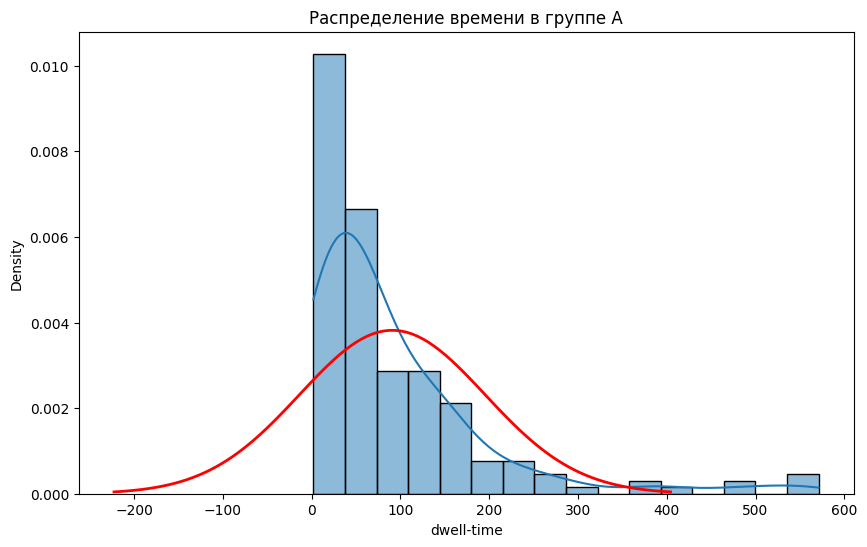

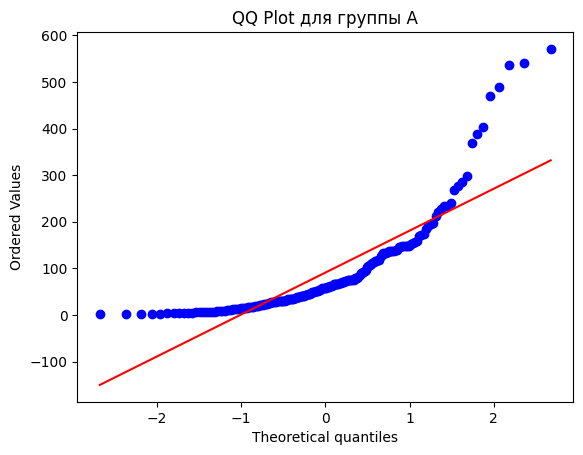

In [37]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Отфильтруем данные группы A
data_a = new[new['site'] == 0]['dwell-time']

# Проверка нормальности Shapiro-Wilk
statistic, p_value = stats.shapiro(data_a)
print(f"Shapiro-Wilk: statistic={statistic}, p-value={p_value:.4f}")

# Гистограмма с нормальным распределением
plt.figure(figsize=(10, 6))
sns.histplot(data_a, kde=True, stat="density")
mu, sigma = data_a.mean(), data_a.std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), color='r', lw=2)
plt.title("Распределение времени в группе A")
plt.show()

# QQ-Plot
stats.probplot(data_a, dist="norm", plot=plt)
plt.title("QQ Plot для группы A")
plt.show()

In [41]:
import pandas as pd
from scipy import stats

# Загрузим данные
file_path = r'C:\\Users\\Admin\\Desktop\\Data_pandas\\new-site.csv'
data = pd.read_csv(file_path, sep='\\t')

# Выделим интересующую колонку (например, время на сайте)
mask_b = new['site'] == 0
sum_group_b = new.loc[mask_b, 'dwell-time']

dwell_time = sum_group_b

# Применим критерий Шапиро-Вилка
shapiro_result = stats.shapiro(dwell_time)

# Вывод результатов
print(f'Statistics: {shapiro_result.statistic}')
print(f'p-value: {shapiro_result.pvalue}')

if shapiro_result.pvalue > 0.05:
    print("Данные не отклоняются от нормального распределения.")
else:
    print("Данные не соответствуют нормальному распределению.")

Statistics: 0.731232632199737
p-value: 4.499873552750829e-17
Данные не соответствуют нормальному распределению.


C:\Users\Admin\AppData\Local\Temp\ipykernel_18212\1490926455.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(file_path, sep='\\t')
